In [9]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [10]:
mlflow.set_tracking_uri("file:///D:/ai-projects/mlops-churn-pipeline/mlruns")

In [12]:
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("churn-prediction")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.roc_auc DESC"],
    max_results=1
)

In [14]:
import mlflow
import mlflow.sklearn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mlflow.set_tracking_uri("http://127.0.0.1:5000")

client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("churn-prediction")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.roc_auc DESC"],
    max_results=1
)
best_run = runs[0]
print(f"Loading model from run: {best_run.data.tags.get('mlflow.runName')}")
print(f"ROC-AUC: {best_run.data.metrics['roc_auc']:.4f}")

model_uri = f"runs:/{best_run.info.run_id}/model"
pipeline = mlflow.sklearn.load_model(model_uri)
print("✓ Model loaded successfully")

Loading model from run: LogisticRegression
ROC-AUC: 0.8420
✓ Model loaded successfully


In [16]:
# Extract preprocessor and model from pipeline
preprocessor = pipeline.named_steps['preprocessor']
model = pipeline.named_steps['model']

# Get feature names after one-hot encoding
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = preprocessor.named_transformers_['cat']\
               .named_steps['onehot'].get_feature_names_out()
all_features = list(num_features) + list(cat_features)

In [17]:
# Get feature importances
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
else:
    # Logistic Regression uses coefficients
    importances = np.abs(model.coef_[0])

feat_df = pd.DataFrame({
    'feature':    all_features,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

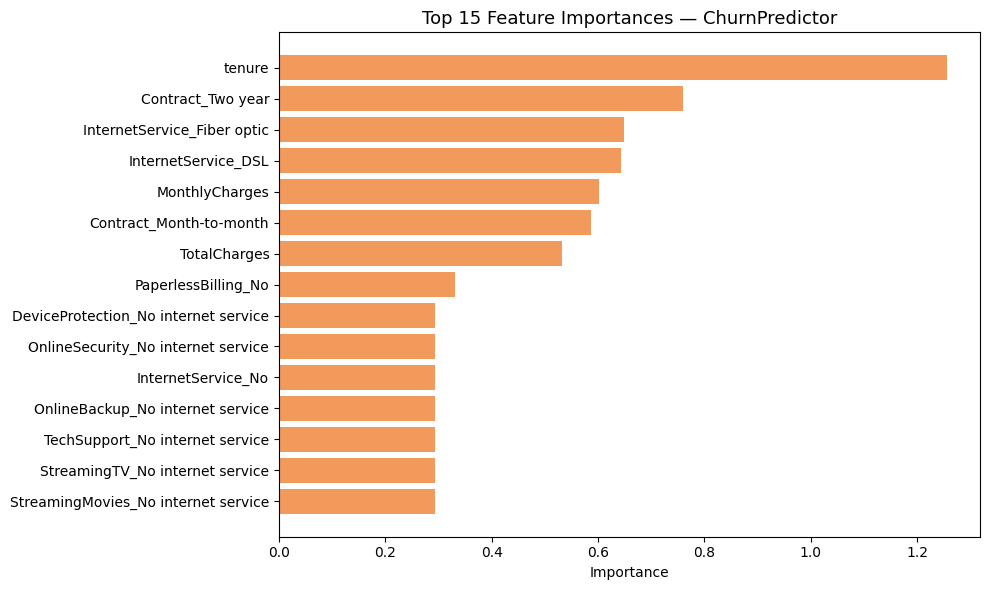


Top 5 features:
                    feature  importance
                     tenure    1.255202
          Contract_Two year    0.759402
InternetService_Fiber optic    0.648027
        InternetService_DSL    0.643642
             MonthlyCharges    0.601168


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1],
        color='#f0883e', alpha=0.85)
ax.set_title('Top 15 Feature Importances — ChurnPredictor', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(feat_df[['feature','importance']].head(5).to_string(index=False))